In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../pagn"))

import numpy as np
import warnings
from astropy import units as u
from astropy.constants import c
from matplotlib import pyplot as plt
import seaborn as sns

from disktab import AGNDisk
from generate_pagn_disk import generate_pagn_csv

DISK_TAB = "../../SpaceHub/src/interaction/disk_tab"

## Generate disktab default
M = 10⁸ M☉, α = 0.1, Ṁ = 0.5 Ṁ_Edd, ε = 0.1, 5000 pts (10–10⁹ Rg)

In [2]:
M     = 1e8 * u.Msun
alpha = 0.1
eta   = 0.1
le    = 0.5

L_edd = 1.26e38 * (M / u.Msun) * u.erg / u.s
Mdot  = le * L_edd / (eta * c * c)

disk       = AGNDisk()
disk.M     = M
disk.alpha = alpha
disk.Mdot  = Mdot

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    df_default = disk.spacehub_pretab(rvals=np.logspace(1, 9, 5000))
    for wi in w:
        print(wi.message)

out = f"{DISK_TAB}/disk_default.csv"
df_default.to_csv(out, index=False)
print(f"Wrote {len(df_default)} rows to {out}")

Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [1503, 1703) around index 1603 (R/Rg ≈ 3675.5) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
Wrote 5000 rows to ../../SpaceHub/src/interaction/disk_tab/disk_default.csv


## Generate pagn default
M = 10⁸ M☉, α = 0.1, le = 0.5, ε = 0.1, N = 5000

In [3]:
out_pagn = f"{DISK_TAB}/disk_default_pagn.csv"
df_pagn = generate_pagn_csv(M_msun=1e8, alpha=0.1, le=0.5, eps=0.1,
                            N=5000, output_path=out_pagn)

Wrote 5000 rows to ../../SpaceHub/src/interaction/disk_tab/disk_default_pagn.csv


### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 1.298344e+00 MSun/yr
le = 0.5
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.1
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Q<1 at i=1965 (R=1.67e+03 Rs)
Beginning star formation at index 1965
Mdisk = 155232084.17889547 Msun
Mdisk/Mbh = 1.5523208417889545

/home/mars/Computing/AGN/SpaceHub-Tinkering/disktab/pagn/generate_pagn_disk.py:188: UserWarning: Zone boundary smoothing applied (CubicHermiteSpline, n_gap=100, w=100): 200 rows [1865, 2065) around index 1965 (R/Rg ≈ 3349.6) replaced for grad_P and grad_Sigma. Originals preserved in grad_P_raw / grad_Sigma_raw.
  _smooth_zone_gradients(df, n_gap=100, w=100)


## Disk profiles

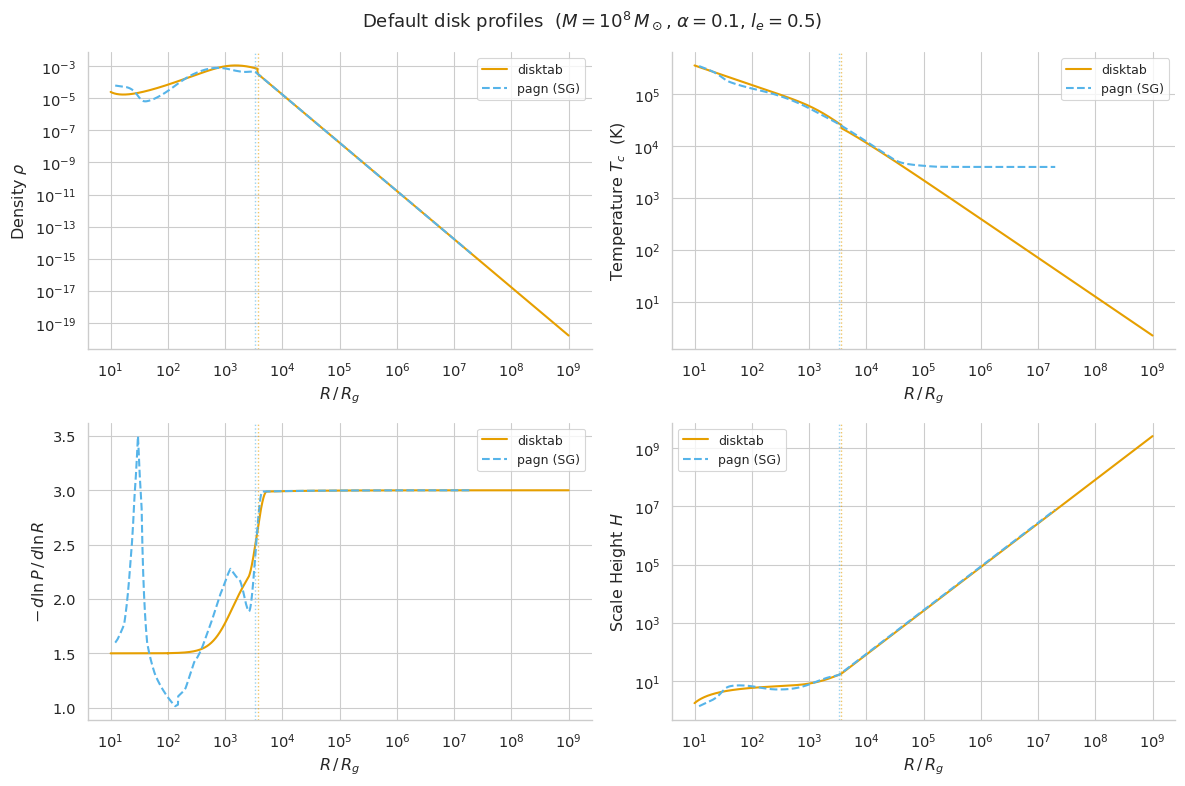

In [4]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

panels = [
    ("rho",    r"Density $\rho$"),
    ("Tc",     r"Temperature $T_c$  (K)"),
    ("grad_P", r"$-\,d\ln P\,/\,d\ln R$"),
    ("H",      r"Scale Height $H$"),
]

OKABE = ["#E69F00", "#56B4E9"]  # orange, sky blue

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (col, ylabel) in zip(axes.flat, panels):
    ax.plot(df_default["R/Rg"], df_default[col],
            color=OKABE[0], lw=1.5, label="disktab")
    ax.plot(df_pagn["R/Rg"], df_pagn[col],
            color=OKABE[1], lw=1.5, ls="--", label="pagn (SG)")

    # Mark Q=1 boundary if present
    for df, c_ in [(df_default, OKABE[0]), (df_pagn, OKABE[1])]:
        if "zone" in df.columns:
            sr = np.where(df["zone"].values == "Self-Reg")[0]
            if len(sr):
                ax.axvline(df["R/Rg"].iloc[sr[0]], color=c_,
                           ls=":", lw=1, alpha=0.6)

    ax.set_xscale("log")
    if col != "grad_P":
        ax.set_yscale("log")
    ax.set_xlabel(r"$R\,/\,R_g$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

sns.despine()
fig.suptitle(r"Default disk profiles  ($M=10^8\,M_\odot$, $\alpha=0.1$, $l_e=0.5$)",
             fontsize=13)
plt.tight_layout()
plt.show()